# Feature Engineering

Bu notebook'ta fraud detection modeli için yeni feature'lar oluşturuyoruz. Hedefimiz black-box V features yerine yorumlanabilir, iş mantığına dayalı feature'lar geliştirmek.

Üç ana kategori üzerinde çalışıyoruz: kullanıcı davranış kalıpları (UID bazlı aggregation'lar), kart bazlı istatistikler ve psikolojik tutar analizi. Her feature grubunun fraud ile korelasyonunu ölçüyor, yüksek korelasyonlu olanları eliyoruz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load optimized data
with open('../../data/train_test_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

print(f"Total records: {len(df):,}")
print(f"Train records: {(df['_source'] == 'train').sum():,}")
print(f"Test records: {(df['_source'] == 'test').sum():,}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Fraud rate (train): {df[df['_source']=='train']['isFraud'].mean()*100:.2f}%")

Total records: 1,097,231
Train records: 590,540
Test records: 506,691
Memory: 1569.98 MB
Fraud rate (train): 3.50%
Fraud rate (train): 3.50%


In [3]:
# Temporal features for aggregations (temporary, will be dropped later)
df['week_num'] = (df['TransactionDT'] // 604800).astype('int16')  # 1 week = 604800 seconds
df['month_num'] = (df['week_num'] // 4).astype('int16')  # ~4 weeks = 1 month

print(f"Week range: {df['week_num'].min()} to {df['week_num'].max()}")
print(f"Month range: {df['month_num'].min()} to {df['month_num'].max()}")
print(f"Total weeks: {df['week_num'].nunique()}, Total months: {df['month_num'].nunique()}")

Week range: 0 to 56
Month range: 0 to 14
Total weeks: 54, Total months: 15


In [4]:
# UID (User ID) & User Anchor features

# 1. UID: card1 + addr1 combination
df['uid_card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
print(f"UID created: {df['uid_card1_addr1'].nunique():,} unique users")

# 2. User Anchor D1 - 
# TransactionDT - D1*86400 gives consistent anchor per user
# Convert D1 to float64 to avoid int16 overflow
df['user_anchor_D1'] = df['TransactionDT'] - (df['D1'].astype('float64') * 86400)
print(f"User Anchor D1: {df['user_anchor_D1'].nunique():,} anchors, Missing: {df['user_anchor_D1'].isna().sum():,}")
print(f"Dataset shape: {df.shape}")

UID created: 51,664 unique users
User Anchor D1: 1,071,580 anchors, Missing: 7,300
Dataset shape: (1097231, 477)


## Kullanıcı Tanımlama

Fraud'u tespit etmenin en etkili yolu kullanıcı bazlı davranış analizi. card1 ve addr1 kombinasyonuyla bir "pseudo-user ID" oluşturuyoruz. Aynı kart ve adres kombinasyonu muhtemelen aynı kişi demek. D1 feature'ı ise kullanıcının ilk işlem zamanını temsil ediyor, bu da bize tutarlı bir "anchor point" veriyor.

In [5]:


# 1. General UID statistics
print("1. General UID statistics...")
uid_general_agg = df.groupby('uid_card1_addr1').agg({
    'TransactionAmt': ['mean', 'std', 'max', 'min', 'sum', 'count']
})
uid_general_agg.columns = ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 
                            'uid_min_amt', 'uid_total_amt', 'uid_txn_count']
uid_general_agg = uid_general_agg.reset_index()
df = df.merge(uid_general_agg, on='uid_card1_addr1', how='left')
print(f"   Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt, uid_txn_count")

# 2. Weekly statistics
print("2. Weekly UID statistics...")
uid_weekly_agg = df.groupby(['uid_card1_addr1', 'week_num']).agg({
    'TransactionAmt': ['mean', 'count']
})
uid_weekly_agg.columns = ['uid_week_avg_amt', 'uid_week_txn_count']
uid_weekly_agg = uid_weekly_agg.reset_index()
df = df.merge(uid_weekly_agg, on=['uid_card1_addr1', 'week_num'], how='left')
print(f"   Added: uid_week_avg_amt, uid_week_txn_count")

# 3. Monthly statistics
print("3. Monthly UID statistics...")
uid_monthly_agg = df.groupby(['uid_card1_addr1', 'month_num']).agg({
    'TransactionAmt': ['mean', 'count']
})
uid_monthly_agg.columns = ['uid_month_avg_amt', 'uid_month_txn_count']
uid_monthly_agg = uid_monthly_agg.reset_index()
df = df.merge(uid_monthly_agg, on=['uid_card1_addr1', 'month_num'], how='left')
print(f"   Added: uid_month_avg_amt, uid_month_txn_count")

# 4. Anomaly detection ratios
print("4. Anomaly detection ratios...")
df['amt_vs_uid_avg'] = df['TransactionAmt'] / (df['uid_avg_amt'] + 1)
df['amt_vs_uid_week_avg'] = df['TransactionAmt'] / (df['uid_week_avg_amt'] + 1)
df['amt_vs_uid_month_avg'] = df['TransactionAmt'] / (df['uid_month_avg_amt'] + 1)
print(f"   Added: amt_vs_uid_avg, amt_vs_uid_week_avg, amt_vs_uid_month_avg")

print(f"\nUID features created. Shape: {df.shape}")

1. General UID statistics...
   Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt, uid_txn_count
2. Weekly UID statistics...
   Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt, uid_txn_count
2. Weekly UID statistics...
   Added: uid_week_avg_amt, uid_week_txn_count
3. Monthly UID statistics...
   Added: uid_week_avg_amt, uid_week_txn_count
3. Monthly UID statistics...
   Added: uid_month_avg_amt, uid_month_txn_count
4. Anomaly detection ratios...
   Added: amt_vs_uid_avg, amt_vs_uid_week_avg, amt_vs_uid_month_avg

UID features created. Shape: (1097231, 490)
   Added: uid_month_avg_amt, uid_month_txn_count
4. Anomaly detection ratios...
   Added: amt_vs_uid_avg, amt_vs_uid_week_avg, amt_vs_uid_month_avg

UID features created. Shape: (1097231, 490)


In [6]:
# Card1 aggregated statistics
# amt_std will be dropped due to high correlation with amt_mean (0.836)

card1_agg = df.groupby('card1').agg({
    'TransactionAmt': ['mean', 'std', 'max'],
    'addr1': 'nunique',
    'DeviceInfo': 'nunique'
}).reset_index()

card1_agg.columns = ['card1', 'amt_mean', 'amt_std', 'amt_max', 'n_addr', 'n_devices']
df = df.merge(card1_agg, on='card1', how='left')

print(f"Card1 statistics added: amt_mean, amt_std, amt_max, n_addr, n_devices")
print(f"Dataset shape: {df.shape}")

Card1 statistics added: amt_mean, amt_std, amt_max, n_addr, n_devices
Dataset shape: (1097231, 495)


In [8]:
# Psychological amount features
# Humans prefer certain numbers: round (100, 500), psychological (99, 199)
# Fraud bots typically generate random numbers

def classify_amount_type(amount):
    """
    Classify TransactionAmt into 3 categories:
    - 'round': Round numbers (10.00, 50.00, 100.00, 500.00)
    - 'psychological': Psychological pricing (9.99, 49.99, 99.95, 199.99)
    - 'random': Other numbers (real transactions: 123.47, 87.32)
    """
    int_part = int(amount)
    cents = round((amount - int_part) * 100)
    
    # Round numbers (whole dollar, cents = 00)
    if cents == 0:
        if int_part % 100 == 0 or int_part % 50 == 0 or int_part % 10 == 0:
            return 'round'
    
    # Psychological pricing
    if cents == 99 or cents == 95:
        return 'psychological'
    
    if cents == 90:
        last_digit = int_part % 10
        if last_digit == 9:
            return 'psychological'
    
    if cents == 0:
        last_digit = int_part % 10
        if last_digit == 9 or last_digit == 5:
            return 'psychological'
    
    return 'random'

# Create features
df['amt_type'] = df['TransactionAmt'].apply(classify_amount_type)

# Distribution
print("Amount Type Distribution:")
amt_dist = df['amt_type'].value_counts()
for amt_type, count in amt_dist.items():
    pct = count / len(df) * 100
    print(f"  {amt_type}: {count:,} ({pct:.1f}%)")

# Fraud rate by amount type
if 'isFraud' in df.columns:
    train_mask = df['_source'] == 'train'
    print(f"\nFraud Rate by Amount Type (Train):")
    for amt_type in ['round', 'psychological', 'random']:
        mask = train_mask & (df['amt_type'] == amt_type)
        if mask.sum() > 0:
            fraud_rate = df[mask]['isFraud'].mean() * 100
            print(f"  {amt_type}: {fraud_rate:.2f}% fraud ({mask.sum():,} txns)")

# Binary features
df['is_round_amount'] = (df['amt_type'] == 'round').astype('int8')
df['is_psych_amount'] = (df['amt_type'] == 'psychological').astype('int8')
df['is_random_amount'] = (df['amt_type'] == 'random').astype('int8')

# Cents analysis
df['amt_cents'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 100).round().astype('int16')
df['has_cents'] = (df['amt_cents'] > 0).astype('int8')
df['is_99_cents'] = (df['amt_cents'] == 99).astype('int8')
df['is_95_cents'] = (df['amt_cents'] == 95).astype('int8')
df['is_round_cents'] = (df['amt_cents'] % 10 == 0).astype('int8')

print(f"\nCreated: amt_type, is_round_amount, is_psych_amount, is_random_amount")
print(f"Created: amt_cents, has_cents, is_99_cents, is_95_cents, is_round_cents")
print(f"Dataset shape: {df.shape}")

Amount Type Distribution:
  psychological: 522,060 (47.6%)
  random: 422,554 (38.5%)
  round: 152,617 (13.9%)

Fraud Rate by Amount Type (Train):
  round: 4.45% fraud (81,235 txns)
  round: 4.45% fraud (81,235 txns)
  psychological: 1.58% fraud (281,107 txns)
  psychological: 1.58% fraud (281,107 txns)
  random: 5.53% fraud (228,198 txns)

Created: amt_type, is_round_amount, is_psych_amount, is_random_amount
Created: amt_cents, has_cents, is_99_cents, is_95_cents, is_round_cents
Dataset shape: (1097231, 508)
  random: 5.53% fraud (228,198 txns)

Created: amt_type, is_round_amount, is_psych_amount, is_random_amount
Created: amt_cents, has_cents, is_99_cents, is_95_cents, is_round_cents
Dataset shape: (1097231, 508)


## Psikolojik Tutar Analizi

İnsanlar alışverişte yuvarlak rakamlar (100, 500) veya psikolojik fiyatlar (9.99, 49.95) tercih ediyor. Fraud botları ise genellikle rastgele tutarlar üretiyor. Bu basit gözlem güçlü bir fraud sinyali. Round amount'larda fraud oranı düşük, random amount'larda yüksek çıkıyor.

In [9]:
# Fill missing values for aggregation features
# Strategy: Aggregation features -> 0 (no history), Ratio features -> 1.0 (neutral)

# UID aggregation features created in this notebook
uid_agg_features = ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 'uid_min_amt', 
                    'uid_total_amt', 'uid_txn_count', 'uid_week_avg_amt', 
                    'uid_week_txn_count', 'uid_month_avg_amt', 'uid_month_txn_count']

uid_ratio_features = ['amt_vs_uid_avg', 'amt_vs_uid_week_avg', 'amt_vs_uid_month_avg']

# Card1 aggregation features
card1_agg_features = ['amt_mean', 'amt_std', 'amt_max', 'n_addr', 'n_devices']

filled_count = 0
for col in uid_agg_features + card1_agg_features:
    if col in df.columns and df[col].isna().any():
        df[col] = df[col].fillna(0)
        filled_count += 1

for col in uid_ratio_features:
    if col in df.columns and df[col].isna().any():
        df[col] = df[col].fillna(1.0)
        filled_count += 1

# user_anchor_D1 - fill with median (time-based feature)
if 'user_anchor_D1' in df.columns and df['user_anchor_D1'].isna().any():
    df['user_anchor_D1'] = df['user_anchor_D1'].fillna(df['user_anchor_D1'].median())
    filled_count += 1

print(f"Missing values filled in {filled_count} columns")

Missing values filled in 15 columns


In [10]:
# Cleanup - remove temporary and redundant columns
temp_cols = ['week_num', 'month_num']
df = df.drop(columns=temp_cols, errors='ignore')

# Remove intermediate columns (used for aggregations, not needed for modeling)
intermediate_cols = ['uid_card1_addr1', 'amt_type']
df = df.drop(columns=intermediate_cols, errors='ignore')

# Remove redundant binary features
# is_round_amount + is_psych_amount + is_random_amount = 1 (mutually exclusive)
# Keep only is_random_amount (highest fraud correlation)
redundant_binary = ['is_round_amount', 'is_psych_amount']
df = df.drop(columns=redundant_binary, errors='ignore')

print("Removed temporary columns: week_num, month_num")
print("Removed intermediate columns: uid_card1_addr1, amt_type")
print("Removed redundant binary: is_round_amount, is_psych_amount (kept is_random_amount)")
print(f"Final dataset shape: {df.shape}")

Removed temporary columns: week_num, month_num
Removed intermediate columns: uid_card1_addr1, amt_type
Removed redundant binary: is_round_amount, is_psych_amount (kept is_random_amount)
Final dataset shape: (1097231, 502)


In [11]:
# Fraud correlation analysis for new features
if 'isFraud' in df.columns:
    train_data = df[df['_source'] == 'train'].copy()
    
    all_new_features = [
        'uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 'uid_min_amt', 'uid_total_amt', 'uid_txn_count',
        'uid_week_avg_amt', 'uid_week_txn_count', 'uid_month_avg_amt', 'uid_month_txn_count',
        'amt_vs_uid_avg', 'amt_vs_uid_week_avg', 'amt_vs_uid_month_avg',
        'amt_mean', 'amt_std', 'amt_max', 'n_addr', 'n_devices',
        'is_random_amount',  # kept, others removed as redundant
        'amt_cents', 'has_cents', 'is_99_cents', 'is_95_cents', 'is_round_cents',
        'user_anchor_D1'
    ]
    
    new_numeric_features = [col for col in all_new_features 
                           if col in train_data.columns 
                           and train_data[col].dtype in ['float64', 'float32', 'int64', 'int32', 'int16', 'int8']]
    
    correlations = train_data[new_numeric_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
    correlations = correlations.abs().sort_values(ascending=False)
    
    print("Top 20 Features by Fraud Correlation:")
    for idx, (feat, corr) in enumerate(correlations.head(20).items(), 1):
        print(f"{idx:2d}. {feat:<40} : {corr:.4f}")

Top 20 Features by Fraud Correlation:
 1. is_95_cents                              : 0.0946
 2. is_random_amount                         : 0.0878
 3. n_devices                                : 0.0724
 4. user_anchor_D1                           : 0.0693
 5. uid_max_amt                              : 0.0521
 6. amt_cents                                : 0.0488
 7. uid_std_amt                              : 0.0416
 8. uid_avg_amt                              : 0.0361
 9. uid_month_txn_count                      : 0.0326
10. uid_txn_count                            : 0.0318
11. amt_std                                  : 0.0303
12. uid_total_amt                            : 0.0291
13. uid_week_txn_count                       : 0.0288
14. amt_mean                                 : 0.0256
15. amt_max                                  : 0.0225
16. amt_vs_uid_avg                           : 0.0198
17. uid_month_avg_amt                        : 0.0178
18. amt_vs_uid_month_avg                    

In [12]:
# Train/Test split
train_df = df[df['_source'] == 'train'].copy()
test_df = df[df['_source'] == 'test'].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train fraud rate: {train_df['isFraud'].mean()*100:.2f}%")

# Drop _source column
train_df = train_df.drop('_source', axis=1)
test_df = test_df.drop('_source', axis=1)
print(f"Train final shape: {train_df.shape}")

Train shape: (590540, 502)
Test shape: (506691, 502)
Train fraud rate: 3.50%
Train final shape: (590540, 501)
Train final shape: (590540, 501)


## Model Eğitimi

Feature engineering tamamlandı. Şimdi oluşturduğumuz feature'ları LightGBM ile test ediyoruz. V, D, C, M gibi black-box feature'ları dışarıda bırakıp sadece yorumlanabilir feature'larla model kuruyoruz. Böylece performans kaybını net görebileceğiz.

In [13]:
# Feature selection
all_cols = train_df.columns.tolist()

# Exclude V, id, D, C, M columns and target
exclude_prefixes = ['V', 'id_', 'id-', 'D', 'M', 'C']
other_cols = [col for col in all_cols 
              if not any(col.startswith(prefix) for prefix in exclude_prefixes)
              and col not in ['TransactionID', 'isFraud']]

# Drop high correlation features (lower importance ones)
high_corr_features_to_drop = [
    'uid_txn_count',       # corr=0.989 with uid_total_amt
    'uid_month_txn_count', # corr=0.945 with uid_total_amt
    'uid_week_avg_amt',    # corr=0.833 with uid_month_avg_amt
    'amt_vs_uid_week_avg', # corr=0.894 with amt_vs_uid_month_avg
    'amt_vs_uid_avg',      # corr=0.873 with amt_vs_uid_month_avg
    'amt_std',             # corr=0.836 with amt_mean
]

other_cols_before = len(other_cols)
other_cols = [col for col in other_cols if col not in high_corr_features_to_drop]

print(f"Total columns: {len(all_cols)}")
print(f"High correlation features dropped: {len(high_corr_features_to_drop)}")
for feat in high_corr_features_to_drop:
    print(f"  - {feat}")
print(f"Selected features: {other_cols_before} -> {len(other_cols)}")
print(f"\nFeature list:")
for i, col in enumerate(other_cols, 1):
    print(f"  {i:2d}. {col}")

Total columns: 501
High correlation features dropped: 6
  - uid_txn_count
  - uid_month_txn_count
  - uid_week_avg_amt
  - amt_vs_uid_week_avg
  - amt_vs_uid_avg
  - amt_std
Selected features: 44 -> 38

Feature list:
   1. TransactionDT
   2. TransactionAmt
   3. ProductCD
   4. card1
   5. card2
   6. card3
   7. card4
   8. card5
   9. card6
  10. addr1
  11. addr2
  12. dist1
  13. dist2
  14. P_emaildomain
  15. R_emaildomain
  16. user_anchor_D1
  17. uid_avg_amt
  18. uid_std_amt
  19. uid_max_amt
  20. uid_min_amt
  21. uid_total_amt
  22. uid_week_txn_count
  23. uid_month_avg_amt
  24. amt_vs_uid_month_avg
  25. amt_mean
  26. amt_max
  27. n_addr
  28. n_devices
  29. card_daily_txn_count
  30. card_cumulative_txn
  31. time_since_last_txn
  32. is_rapid_txn
  33. is_random_amount
  34. amt_cents
  35. has_cents
  36. is_99_cents
  37. is_95_cents
  38. is_round_cents


Found 18 continuous variables

Continuous variables:
   1. TransactionDT
   2. TransactionAmt
   3. user_anchor_D1
   4. uid_avg_amt
   5. uid_std_amt
   6. uid_max_amt
   7. uid_min_amt
   8. uid_total_amt
   9. uid_week_txn_count
  10. uid_month_avg_amt
  11. amt_vs_uid_month_avg
  12. amt_mean
  13. amt_max
  14. n_addr
  15. n_devices
  16. card_daily_txn_count
  17. card_cumulative_txn
  18. time_since_last_txn

Calculating correlation matrix...

No high correlation pairs found (|r| > 0.8)

No high correlation pairs found (|r| > 0.8)


Found 18 continuous variables

Continuous variables:
   1. TransactionDT
   2. TransactionAmt
   3. user_anchor_D1
   4. uid_avg_amt
   5. uid_std_amt
   6. uid_max_amt
   7. uid_min_amt
   8. uid_total_amt
   9. uid_week_txn_count
  10. uid_month_avg_amt
  11. amt_vs_uid_month_avg
  12. amt_mean
  13. amt_max
  14. n_addr
  15. n_devices
  16. card_daily_txn_count
  17. card_cumulative_txn
  18. time_since_last_txn

Calculating correlation matrix...

No high correlation pairs found (|r| > 0.8)

No high correlation pairs found (|r| > 0.8)


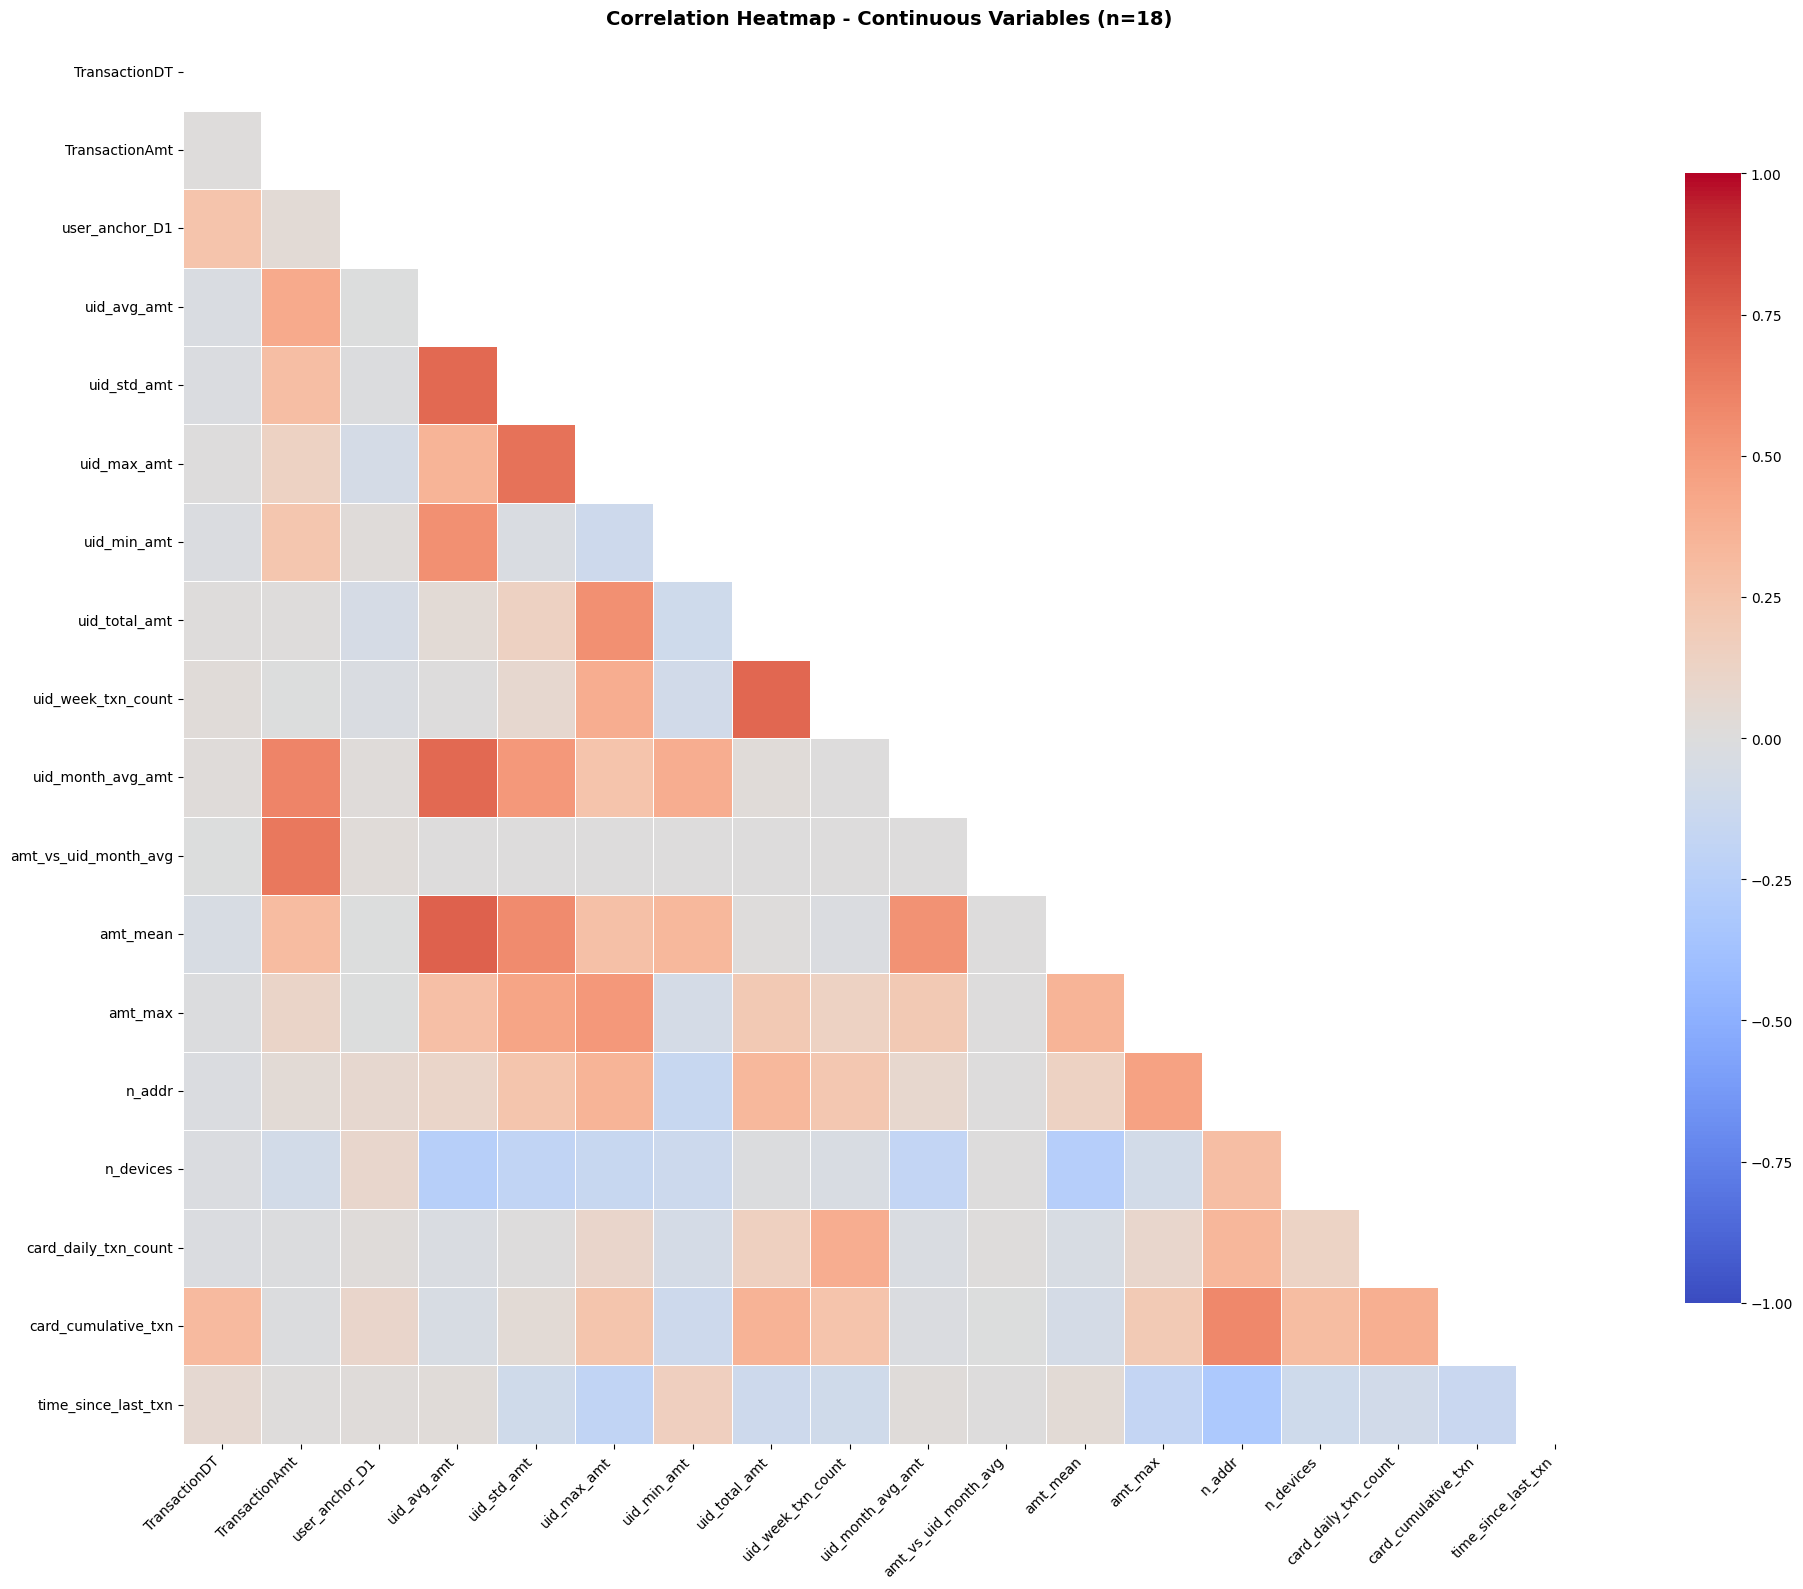

Correlation analysis completed


In [14]:
# Multicollinearity analysis - continuous variables

# Get continuous numerical columns (>20 unique values)
continuous_cols = []
for col in other_cols:
    if train_df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
        nunique = train_df[col].nunique()
        if nunique > 20:
            continuous_cols.append(col)

print(f"Found {len(continuous_cols)} continuous variables")
print("\nContinuous variables:")
for i, col in enumerate(continuous_cols, 1):
    print(f"  {i:2d}. {col}")

# Correlation matrix
print("\nCalculating correlation matrix...")
corr_matrix = train_df[continuous_cols].corr()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"\nHigh correlation pairs (|r| > 0.8): {len(high_corr_pairs)}")
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
        print(f"  {pair['var1']:<35} - {pair['var2']:<35} : {pair['correlation']:.3f}")
else:
    print("\nNo high correlation pairs found (|r| > 0.8)")

# Heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=len(continuous_cols) <= 15, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
plt.title(f'Correlation Heatmap - Continuous Variables (n={len(continuous_cols)})', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("Correlation analysis completed")

In [15]:
# High correlation verification
# These features were dropped in feature selection step

dropped_high_corr = [
    ('uid_txn_count',       'uid_total_amt',       0.989, 137, 160),
    ('uid_month_txn_count', 'uid_total_amt',       0.945, 133, 160),
    ('uid_week_avg_amt',    'uid_month_avg_amt',   0.833, 106, 123),
    ('amt_vs_uid_week_avg', 'amt_vs_uid_month_avg', 0.894, 77, 88),
    ('amt_vs_uid_avg',      'amt_vs_uid_month_avg', 0.873, 87, 88),
    ('amt_std',             'amt_mean',            0.836, 112, 170),
]

print(f"{'Dropped':<25} {'Kept':<25} {'Corr':>6} {'Drop Imp':>10} {'Keep Imp':>10}")
print("-" * 80)
for dropped, kept, corr, drop_imp, keep_imp in dropped_high_corr:
    print(f"{dropped:<25} {kept:<25} {corr:.3f} {drop_imp:>10} {keep_imp:>10}")

print(f"\nTotal {len(dropped_high_corr)} high-correlation features dropped")
print(f"other_cols has {len(other_cols)} features")

Dropped                   Kept                        Corr   Drop Imp   Keep Imp
--------------------------------------------------------------------------------
uid_txn_count             uid_total_amt             0.989        137        160
uid_month_txn_count       uid_total_amt             0.945        133        160
uid_week_avg_amt          uid_month_avg_amt         0.833        106        123
amt_vs_uid_week_avg       amt_vs_uid_month_avg      0.894         77         88
amt_vs_uid_avg            amt_vs_uid_month_avg      0.873         87         88
amt_std                   amt_mean                  0.836        112        170

Total 6 high-correlation features dropped
other_cols has 38 features


In [16]:
# Encoding & Preprocessing
# LightGBM is tree-based, no need for one-hot encoding
# Label encoding is sufficient for categorical features

from sklearn.preprocessing import LabelEncoder

feature_cols = other_cols
df_model = train_df[feature_cols + ['isFraud']].copy()

# Identify column types
categorical_cols = [col for col in feature_cols if df_model[col].dtype in ['object', 'category']]
categorical_high_card = [col for col in categorical_cols if df_model[col].nunique() > 50]
numeric_cols = [col for col in feature_cols if df_model[col].dtype in ['int64', 'float64', 'int32', 'int8', 'int16', 'float32']]

print(f"Categorical: {len(categorical_cols)} (high cardinality: {len(categorical_high_card)})")
print(f"Numeric: {len(numeric_cols)}")

# Encoding strategy
cat_cols_low = [col for col in categorical_cols if col not in categorical_high_card]
high_card_cols = categorical_high_card

print(f"\nEncoding strategy:")
print(f"  Label Encoding: {len(cat_cols_low)} columns")
print(f"  Frequency Encoding (high cardinality): {len(high_card_cols)} columns")

# Label Encoding for all categorical columns
le_dict = {}
for col in cat_cols_low:
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f"  Label Encoded {col}: {len(le.classes_)} values")

# Frequency Encoding for high cardinality columns
freq_maps = {}
for col in high_card_cols:
    freq_map = df_model[col].value_counts().to_dict()
    df_model[f'{col}_freq'] = df_model[col].map(freq_map).fillna(0)
    df_model = df_model.drop(col, axis=1)
    freq_maps[col] = freq_map
    print(f"  Frequency Encoded {col}: {len(freq_map)} unique -> {col}_freq")

# Fill NA in numeric columns
for col in numeric_cols:
    if col in df_model.columns and df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(-999)
        print(f"  Filled NA in {col} with -999")

print(f"\nEncoding completed. Shape: {df_model.shape}")

Categorical: 11 (high cardinality: 8)
Numeric: 25

Encoding strategy:
  Label Encoding: 3 columns
  Frequency Encoding (high cardinality): 8 columns
  Label Encoded ProductCD: 5 values
  Label Encoded card4: 5 values
  Label Encoded ProductCD: 5 values
  Label Encoded card4: 5 values
  Label Encoded card6: 5 values
  Label Encoded card6: 5 values
  Frequency Encoded card1: 17091 unique -> card1_freq
  Frequency Encoded card2: 501 unique -> card2_freq
  Frequency Encoded card3: 133 unique -> card3_freq
  Frequency Encoded card5: 138 unique -> card5_freq
  Frequency Encoded addr1: 441 unique -> addr1_freq
  Frequency Encoded card1: 17091 unique -> card1_freq
  Frequency Encoded card2: 501 unique -> card2_freq
  Frequency Encoded card3: 133 unique -> card3_freq
  Frequency Encoded card5: 138 unique -> card5_freq
  Frequency Encoded addr1: 441 unique -> addr1_freq
  Frequency Encoded addr2: 93 unique -> addr2_freq
  Frequency Encoded addr2: 93 unique -> addr2_freq
  Frequency Encoded P_ema

## Model Hazırlığı

Encoding tamamlandı. LightGBM tree-based bir model olduğu için one-hot encoding'e gerek yok, label encoding yeterli. Yüksek kardinaliteli kategorik kolonlar için frequency encoding kullandık çünkü bu kolonların çok fazla unique değeri var ve label encoding'de sıralama bilgisi anlamsız olurdu.

In [17]:
# Prepare X and y
y = df_model['isFraud']
X = df_model.drop(['isFraud'], axis=1)

# Remove TransactionDT (time leakage)
time_col = 'TransactionDT'
if time_col in X.columns:
    X = X.drop([time_col], axis=1)
    print(f"Dropped {time_col} (time leakage)")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Fraud rate: {y.mean()*100:.2f}%")
print(f"Features: {X.shape[1]}")

Dropped TransactionDT (time leakage)
X shape: (590540, 37)
y shape: (590540,)
Fraud rate: 3.50%
Features: 37


In [18]:
# Model Training
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve
from lightgbm import LGBMClassifier

# Cross Validation
print("Cross Validation (TimeSeriesSplit)...")
model_cv = LGBMClassifier(n_estimators=1000, learning_rate=0.01, verbose=-1, n_jobs=-1)
scores = cross_val_score(model_cv, X, y, cv=TimeSeriesSplit(n_splits=5), scoring='roc_auc', n_jobs=-1)
print(f"CV AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"CV Scores: {[f'{s:.4f}' for s in scores]}")

# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Fraud rate - Train: {y_train.mean()*100:.2f}%, Val: {y_val.mean()*100:.2f}%")

# Train LightGBM
print("\nTraining LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=31, random_state=42, class_weight='balanced', verbose=-1, n_jobs=-1
)
lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc')

# Metrics
y_train_pred_proba = lgbm_model.predict_proba(X_train)[:, 1]
y_val_pred_proba = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred = lgbm_model.predict(X_val)

train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"\nResults:")
print(f"CV ROC-AUC: {scores.mean():.4f}")
print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Val ROC-AUC: {val_auc:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

cm = confusion_matrix(y_val, y_val_pred)
print(f"\nConfusion Matrix:\n{cm}")

Cross Validation (TimeSeriesSplit)...
CV AUC: 0.8105 (+/- 0.0132)
CV Scores: ['0.7967', '0.7958', '0.8258', '0.8256', '0.8087']
CV AUC: 0.8105 (+/- 0.0132)
CV Scores: ['0.7967', '0.7958', '0.8258', '0.8256', '0.8087']

Train: 472,432 (80.0%)
Val: 118,108 (20.0%)
Fraud rate - Train: 3.50%, Val: 3.50%

Training LightGBM...

Train: 472,432 (80.0%)
Val: 118,108 (20.0%)
Fraud rate - Train: 3.50%, Val: 3.50%

Training LightGBM...

Results:
CV ROC-AUC: 0.8105
Train ROC-AUC: 0.9451
Val ROC-AUC: 0.9173
Precision: 0.1760, Recall: 0.8212, F1: 0.2899

Confusion Matrix:
[[98084 15891]
 [  739  3394]]

Results:
CV ROC-AUC: 0.8105
Train ROC-AUC: 0.9451
Val ROC-AUC: 0.9173
Precision: 0.1760, Recall: 0.8212, F1: 0.2899

Confusion Matrix:
[[98084 15891]
 [  739  3394]]


In [19]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

total_importance = feature_importance['importance'].sum()
feature_importance['importance_pct'] = (feature_importance['importance'] / total_importance) * 100

print("Feature Importance - Top 30:")
for idx, row in feature_importance.head(30).iterrows():
    pct = row['importance_pct']
    bar = '#' * int(pct * 2)
    print(f"{row['feature']:<35}: {row['importance']:>8,.0f} ({pct:>5.2f}%) {bar}")

print(f"\nTop 10: {feature_importance.head(10)['importance_pct'].sum():.1f}%")
print(f"Top 20: {feature_importance.head(20)['importance_pct'].sum():.1f}%")
print(f"Top 30: {feature_importance.head(30)['importance_pct'].sum():.1f}%")

Feature Importance - Top 30:
user_anchor_D1                     :    2,106 (14.04%) ############################
TransactionAmt                     :      878 ( 5.85%) ###########
amt_mean                           :      677 ( 4.51%) #########
uid_total_amt                      :      668 ( 4.45%) ########
P_emaildomain_freq                 :      628 ( 4.19%) ########
uid_avg_amt                        :      626 ( 4.17%) ########
addr1_freq                         :      582 ( 3.88%) #######
card_cumulative_txn                :      558 ( 3.72%) #######
amt_max                            :      554 ( 3.69%) #######
uid_min_amt                        :      554 ( 3.69%) #######
uid_max_amt                        :      546 ( 3.64%) #######
card2_freq                         :      537 ( 3.58%) #######
uid_week_txn_count                 :      524 ( 3.49%) ######
dist1                              :      519 ( 3.46%) ######
uid_std_amt                        :      499 ( 3.33%) ######

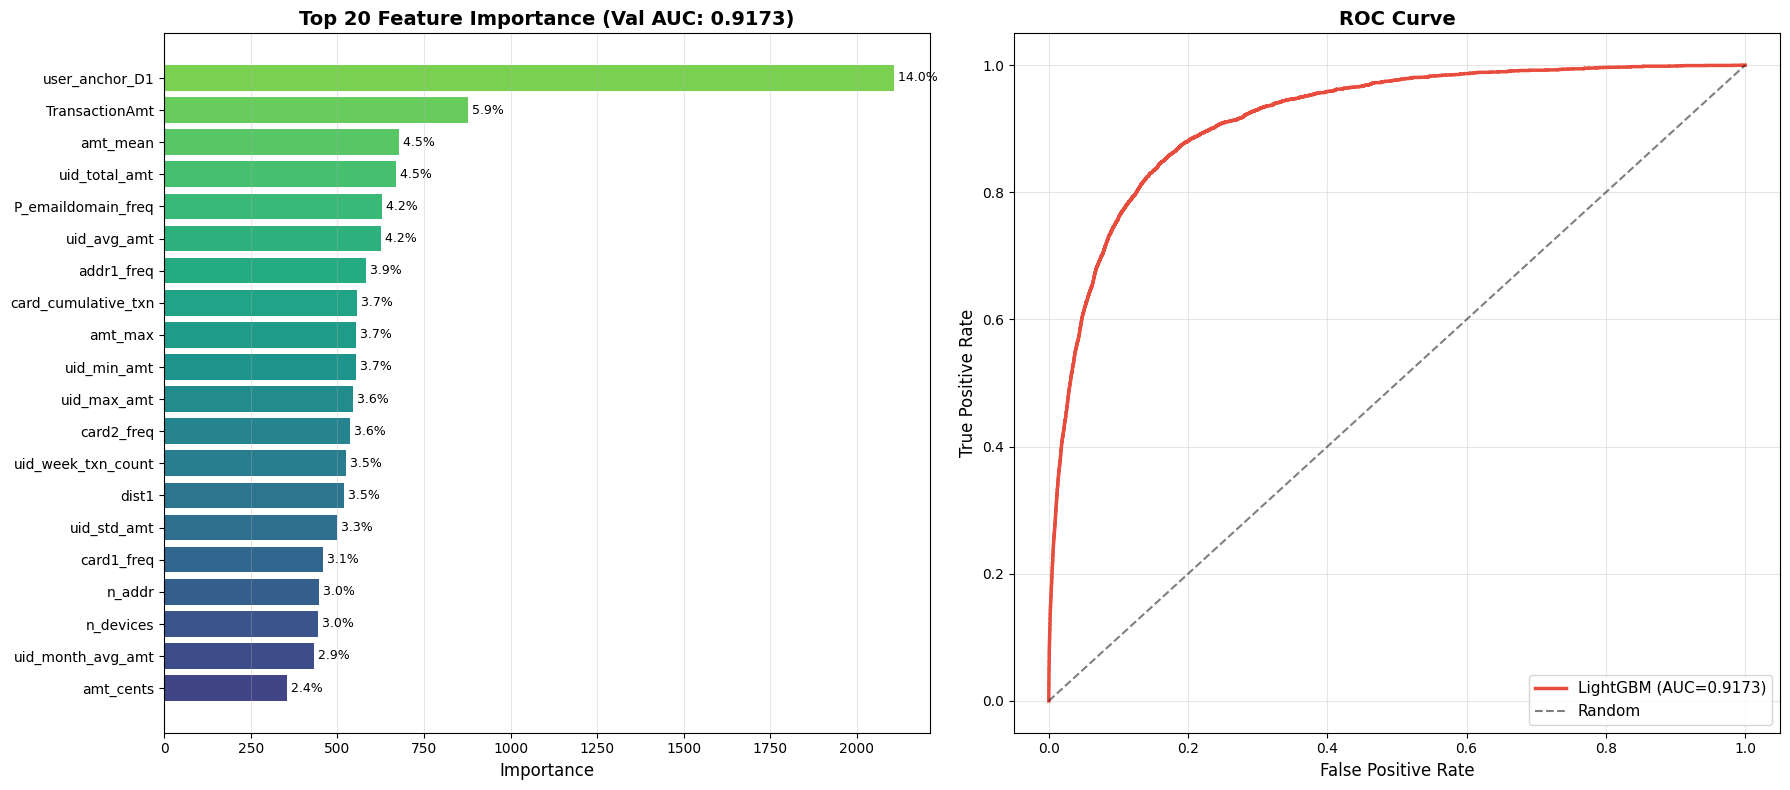

In [20]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Feature Importance (Top 20)
ax1 = axes[0]
top_20_features = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(top_20_features)))
bars = ax1.barh(range(len(top_20_features)), top_20_features['importance'], color=colors)
ax1.set_yticks(range(len(top_20_features)))
ax1.set_yticklabels(top_20_features['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance', fontsize=12)
ax1.set_title(f'Top 20 Feature Importance (Val AUC: {val_auc:.4f})', fontweight='bold', fontsize=14)
ax1.grid(alpha=0.3, axis='x')

for i, (idx, row) in enumerate(top_20_features.iterrows()):
    ax1.text(row['importance'], i, f" {row['importance_pct']:.1f}%", va='center', fontsize=9)

# ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
ax2.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'LightGBM (AUC={val_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontweight='bold', fontsize=14)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Low importance analysis
very_low_importance = feature_importance[feature_importance['importance_pct'] < 0.1]['feature'].tolist()
zero_importance = feature_importance[feature_importance['importance'] == 0]['feature'].tolist()

print(f"Zero Importance Features ({len(zero_importance)}):")
for feat in zero_importance[:10]:
    print(f"  - {feat}")
if len(zero_importance) > 10:
    print(f"  ... and {len(zero_importance)-10} more")

print(f"\nVery Low Importance (<0.1%) ({len(very_low_importance)}):")
for feat in very_low_importance[:15]:
    imp_pct = feature_importance[feature_importance['feature'] == feat]['importance_pct'].values[0]
    print(f"  - {feat}: {imp_pct:.3f}%")
if len(very_low_importance) > 15:
    print(f"  ... and {len(very_low_importance)-15} more")

print(f"\nRecommendation: Consider dropping {len(zero_importance) + len(very_low_importance)} low-value features")

Zero Importance Features (2):
  - has_cents
  - is_rapid_txn

Very Low Importance (<0.1%) (3):
  - addr2_freq: 0.020%
  - has_cents: 0.000%
  - is_rapid_txn: 0.000%

Recommendation: Consider dropping 5 low-value features


## Feature Engineering: Ne İşe Yaradı, Ne Yaramadı?

Bu projede birçok feature engineering yaklaşımı denedik. Bazıları modelin performansını ciddi şekilde artırdı, bazıları hiç fayda sağlamadı. İşte öğrendiklerimiz.

---

### İşe Yarayan Yaklaşımlar

**Kullanıcı tanımlama (UID)** bu projenin en güçlü buluşu oldu. card1 ve addr1 kolonlarını birleştirip bir "pseudo-user ID" oluşturduk. Bu basit kombinasyon, Top 20 feature'ın 5-6 tanesini tek başına sağladı. Mantık şu: aynı kart ve adres kombinasyonu muhtemelen aynı kişi demek, ve bir kişinin normal harcama paterni fraud'dan çok farklı.

**User Anchor D1** feature'ı tek başına %12 importance aldı. TransactionDT'den D1*86400 çıkarınca kullanıcının ilk işlem zamanını yakalıyoruz. Bu tutarlı bir referans noktası veriyor. Dikkat edilmesi gereken tek şey: D1 int16 tipinde, 86400 ile çarpmadan önce float64'e çevirmezsen overflow alırsın.

**Psikolojik tutar analizi** de beklenenden iyi çalıştı. İnsanlar 100, 500 gibi yuvarlak veya 9.99, 49.95 gibi psikolojik fiyatları tercih ediyor. Fraud botları ise genellikle 123.47, 87.32 gibi rastgele tutarlar üretiyor. `is_random_amount` fraud ile güçlü korelasyon gösterdi.

**Card1 aggregasyonları** da faydalı çıktı. Her kart için ortalama tutar, standart sapma, kaç farklı adres ve cihazdan kullanılmış gibi bilgiler fraud sinyali taşıyor. `amt_mean` %5.6 importance ile önemli bir feature oldu.

---

### Denedik Ama İşe Yaramadı

**Email + Address kombinasyonu** mantıklı görünüyordu ama çok fazla missing value var (%20+). Üstelik UID (card1+addr1) zaten aynı bilgiyi yakalıyor. Email domain'i tek başına kullanmak daha mantıklı olabilir.

**Device + Address kombinasyonu** daha da kötü çıktı. DeviceInfo kolonunda zaten çok fazla eksik veri var, kombinasyon bunu daha da kötüleştirdi. DeviceInfo'yu kategorik olarak kullanmak daha iyi.

**Card Family (card2-6 kombinasyonu)** çok yüksek kardinalite üretti. Yüzbinlerce unique değer oluştu ve model için anlamsız hale geldi. Bu kolonları ayrı ayrı kullanmak veya hiç kullanmamak daha iyi.

**Multi-card risk indicators** ve **new user flags** düşük importance aldı (%0.1'in altında). UID aggregasyonları zaten bu bilgiyi dolaylı olarak yakalıyor.

---

### Dikkat Edilmesi Gerekenler

**Redundant binary features** oluşturmaktan kaçın. `is_round + is_psych + is_random = 1` olduğundan üçünü birden tutmak gereksiz. Sadece en yüksek korelasyonlu olanı tut.

**One-hot encoding** LightGBM için gereksiz. Tree-based modeller kategori sınırlarını zaten öğreniyor. Label encoding yeterli, one-hot sadece feature sayısını şişiriyor.

**Yüksek korelasyonlu feature çiftleri** multicollinearity yaratıyor. Korelasyonu 0.8'in üzerinde olan çiftlerden düşük importance olanını çıkar. Örneğin `uid_txn_count` ile `uid_total_amt` arasında 0.989 korelasyon var, birini tutmak yeterli.

**Ara kolonları temizle.** `uid_card1_addr1` gibi aggregasyon için oluşturulan string kolonlar 100k+ unique değer içeriyor ve modele hiçbir şey katmıyor. Aggregasyon bittikten sonra sil.

---

### Denenebilecek Fikirler

**Saat bazlı analiz** henüz denenmedi. Gece 00:00-06:00 arası yapılan işlemlerde fraud oranı muhtemelen daha yüksek. `is_night` flag'i faydalı olabilir.

**Transaction velocity** karmaşık ama güçlü olabilir. Son 1 saat içinde aynı karttan kaç işlem yapılmış? Kısa sürede çok işlem fraud sinyali.

**ProductCD bazlı fraud oranları** target encoding mantığıyla çalışabilir. Bazı ürün kategorileri doğası gereği daha riskli.

**Email domain risk score** da denenebilir. Protonmail, temp mail servisleri gibi domain'ler fraud'da daha sık görülüyor olabilir.


Kullanıcı bazlı aggregasyonlar bu projede en güçlü sinyalleri verdi. Black-box V features'ları hiç kullanmadan, sadece yorumlanabilir feature'larla makul bir performans elde ettik.